x0 = 4, alpha1 = 0.5, alpha2 = 0.5


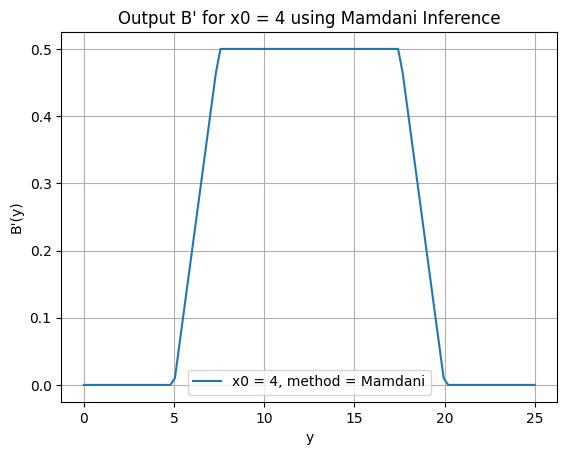

x0 = 3.5, alpha1 = 0.75, alpha2 = 0.25


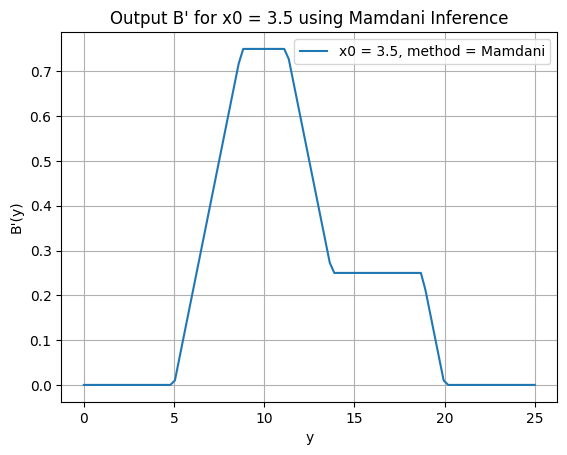

x0 = 4, alpha1 = 0.5, alpha2 = 0.5


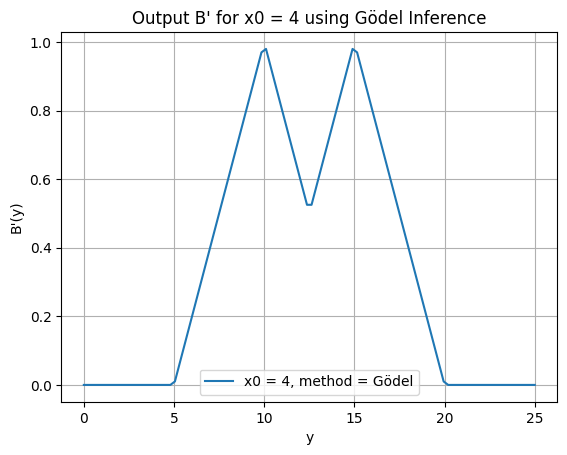

x0 = 3.5, alpha1 = 0.75, alpha2 = 0.25


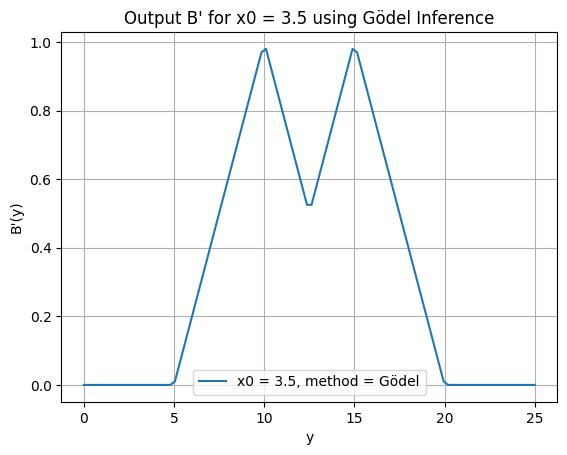

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Funciones de membresía para A1 y A2
def A1(x):
    return max(0, min((x - 1) / (3 - 1), (5 - x) / (5 - 3)))

def A2(x):
    return max(0, min((x - 3) / (5 - 3), (7 - x) / (7 - 5)))

# Funciones de membresía para B1 y B2
def B1(y):
    return max(0, min((y - 5) / (10 - 5), (15 - y) / (15 - 10)))

def B2(y):
    return max(0, min((y - 10) / (15 - 10), (20 - y) / (20 - 15)))

# Calcular y graficar la salida difusa
def plot_fuzzy_output(x0, y_values, method="Mamdani"):
    alpha1 = A1(x0)
    alpha2 = A2(x0)
    print(f"x0 = {x0}, alpha1 = {alpha1}, alpha2 = {alpha2}")

    if method == "Mamdani":
        def B_prime(y):
            return max(min(alpha1, B1(y)), min(alpha2, B2(y)))
    elif method == "Gödel":
        def B_prime(y):
            return max(min(1, B1(y) if alpha1 > 0 else 0), min(1, B2(y) if alpha2 > 0 else 0))

    B_prime_values = [B_prime(y) for y in y_values]

    plt.plot(y_values, B_prime_values, label=f"x0 = {x0}, method = {method}")
    plt.xlabel('y')
    plt.ylabel("B'(y)")
    plt.title(f"Output B' for x0 = {x0} using {method} Inference")
    plt.legend()
    plt.grid(True)
    plt.show()

# Valores de y
y_values = np.linspace(0, 25, 100)

# Caso a: x0 = 4
plot_fuzzy_output(4, y_values, "Mamdani")

# Caso b: x0 = 3.5
plot_fuzzy_output(3.5, y_values, "Mamdani")

# Caso c: Comparación con Gödel
plot_fuzzy_output(4, y_values, "Gödel")
plot_fuzzy_output(3.5, y_values, "Gödel")